In [1]:
!pip install -q diffusers transformers accelerate safetensors

In [2]:
import torch
from diffusers import AutoPipelineForImage2Image
from diffusers.utils import load_image
from PIL import Image
from google.colab import files

pipe = AutoPipelineForImage2Image.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
    torch_dtype=torch.float16,
    safety_checker=None,
).to("cuda")
pipe.enable_attention_slicing()

[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_img2img.StableDiffusionImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Saving 134111172756186053.jpg to 134111172756186053.jpg


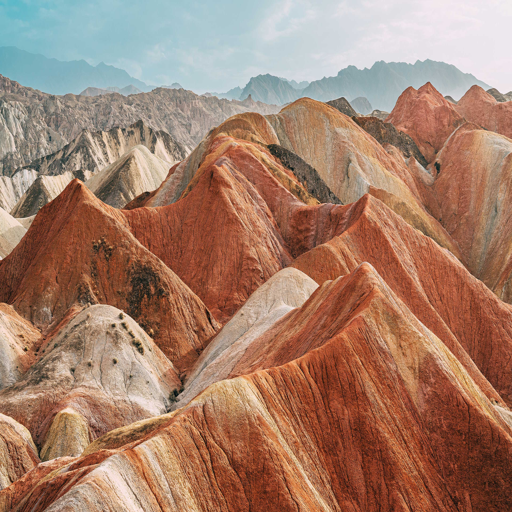

In [7]:
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
init_image = Image.open(img_path).convert("RGB").resize((512, 512))
init_image

Enter your prompt: the same scene at night, moonlight, cinematic
Negative prompt (optional, press Enter to skip): 
Strength 0.1-1.0 (default 0.6): 0.3


  0%|          | 0/9 [00:00<?, ?it/s]

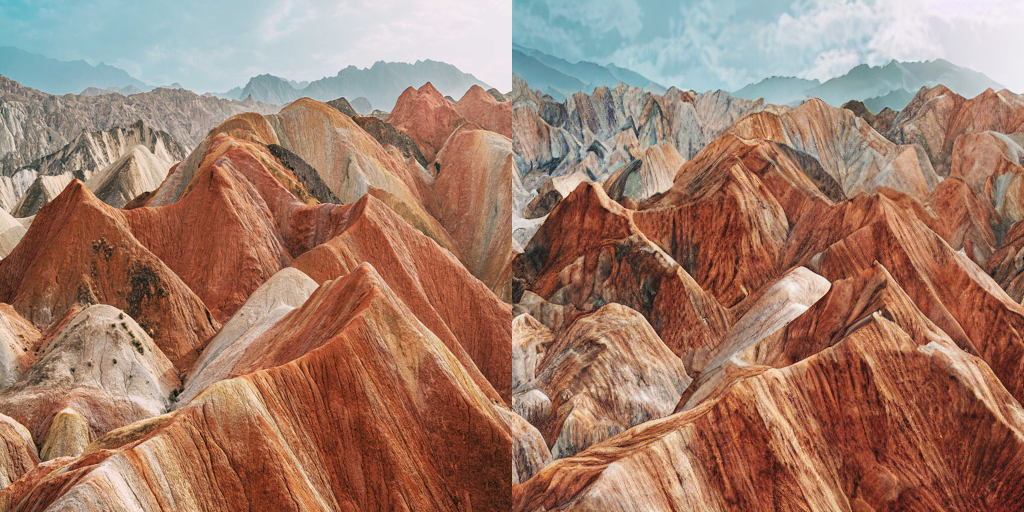

In [10]:
prompt = input("Enter your prompt: ")
negative = input("Negative prompt (optional, press Enter to skip): ")
strength = float(input("Strength 0.1-1.0 (default 0.6): ") or 0.6)

result = pipe(
    prompt=prompt,
    negative_prompt=negative or None,
    image=init_image,
    strength=strength,
    guidance_scale=7.5,
    num_inference_steps=30,
).images[0]

result.save("output.png")

# show input and output side by side
combined = Image.new("RGB", (1024, 512))
combined.paste(init_image, (0, 0))
combined.paste(result, (512, 0))
combined